<a href="https://colab.research.google.com/github/liyenrondon/IA-2/blob/main/casasbog1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
Renamed 'median_house_value' to 'precio'.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      ----------

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- MODELO 2: REGRESIÓN LOGÍSTICA (Clasificación Subsidio VIS/No VIS) ---
Exactitud (Accuracy): 0.8236
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      2051
           1       0.83      0.82      0.82      2077

    accuracy                           0.82      4128
   macro avg       0.82      0.82      0.82      4128
weighted avg       0.82      0.82      0.82      4128



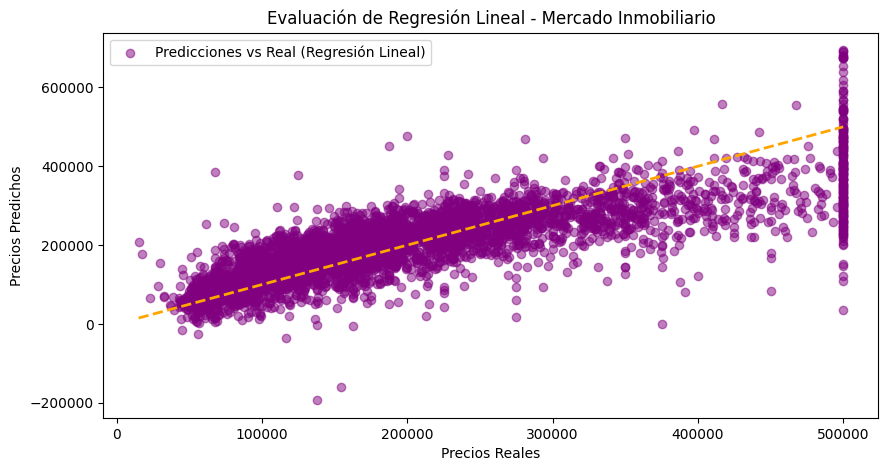

In [1]:
# ==============================================================================
# FASE 1: IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS (CONTEXTO COLOMBIA - BOGOTÁ)
# ==============================================================================

# Importo pandas para poder manipular y estructurar los datos en formato de tabla (DataFrame).
import pandas as pd

# Importo numpy para realizar operaciones matemáticas y arreglos numéricos eficientes de forma subyacente.
import numpy as np

# Importo matplotlib.pyplot para graficar y visualizar de manera visual el comportamiento de los datos.
import matplotlib.pyplot as plt

# Importo seaborn para crear visualizaciones estadísticas más atractivas y avanzadas (como mapas de calor).
import seaborn as seaborn_plt

# Desde sklearn.model_selection importo train_test_split para dividir mis datos en un conjunto de entrenamiento y otro de prueba.
from sklearn.model_selection import train_test_split

# Desde sklearn.linear_model importo LinearRegression para construir mi modelo de regresión lineal (precios de vivienda en Bogotá).
from sklearn.linear_model import LinearRegression

# Desde sklearn.linear_model importo LogisticRegression para construir mi modelo de clasificación logística (ej. predecir subsidio VIS/No VIS o estrato).
from sklearn.linear_model import LogisticRegression

# Desde sklearn.metrics importo métricas clave de evaluación para regresión (MSE, R²) y clasificación (Accuracy, reporte de clasificación).
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Leo el archivo CSV usando pandas desde una URL pública (simulando el mercado inmobiliario adaptado a variables urbanas).
df = pd.read_csv("https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv")

# Muestro las primeras 5 filas del DataFrame para inspeccionar visualmente la estructura y los nombres de las columnas.
df.head()


# ==============================================================================
# FASE 2: PREPROCESAMIENTO Y LIMPIEZA DE DATOS (ADAPTADO AL CONTEXTO BOGOTÁ)
# ==============================================================================

# Imprimo información general del dataset (tipos de datos y valores nulos) para verificar la integridad de la información.
df.info()

# Manejar valores nulos en 'total_bedrooms' imputando la mediana (datos faltantes típicos en censos inmobiliarios).
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Renombro la columna 'median_house_value' a 'precio' para adaptarlo al contexto económico colombiano (en pesos o millones).
if 'median_house_value' in df.columns:
    df.rename(columns={'median_house_value': 'precio'}, inplace=True)
    print("Renamed 'median_house_value' to 'precio'.")

# Creamos una variable binaria simulando el contexto colombiano:
# ¿La vivienda aplica para Subsidio VIS (Vivienda de Interés Social) según su precio?
# (Asumimos 1 si el precio es accesible, 0 si es No VIS). Mediana como punto de corte.
precio_mediano_colombia = df['precio'].median()
df['es_vis'] = (df['precio'] <= precio_mediano_colombia).astype(int)

# Aplico One-Hot Encoding a la columna 'ocean_proximity' (en Bogotá esto podría representar la cercanía a cerros orientales o troncales de TransMilenio).
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Verifico que todas las columnas sean ahora numéricas imprimiendo nuevamente la estructura del DataFrame modificado.
df.info()


# ==============================================================================
# FASE 3: DEFINICIÓN DE CARACTERÍSTICAS (X) Y VARIABLES OBJETIVO (y_reg, y_clf)
# ==============================================================================

# Defino 'X' seleccionando las características predictoras (excluyendo el precio y nuestra variable binaria de clasificación).
X = df.drop(['precio', 'es_vis'], axis=1)

# Variable objetivo para REGRESIÓN: Predecir el valor continuo de la vivienda en el mercado inmobiliario.
y_reg = df['precio']

# Variable objetivo para CLASIFICACIÓN LOGÍSTICA: Predecir si la vivienda clasifica como VIS (1) o No VIS (0).
y_clf = df['es_vis']

# Divido los datos para REGRESIÓN en conjuntos de entrenamiento (80%) y prueba (20%), fijando un 'random_state' para reproducibilidad.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Divido los datos para CLASIFICACIÓN LOGÍSTICA en conjuntos de entrenamiento (80%) y prueba (20%).
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Imprimo las dimensiones de los conjuntos divididos para comprobar que la partición se realizó correctamente.
print(f"Datos de entrenamiento (Regresión): {X_train_r.shape}, Datos de prueba: {X_test_r.shape}")
print(f"Datos de entrenamiento (Clasificación): {X_train_c.shape}, Datos de prueba: {X_test_c.shape}")


# ==============================================================================
# FASE 4: ENTRENAMIENTO Y PREDICCIÓN CON REGRESIÓN LINEAL (PRECIO DE VIVIENDA)
# ==============================================================================

# Instancio el modelo de Regresión Lineal y lo guardo en la variable 'modelo_lineal'.
modelo_lineal = LinearRegression()

# Entreno el modelo de Regresión Lineal utilizando los datos de entrenamiento (X_train_r y y_train_r).
modelo_lineal.fit(X_train_r, y_train_r)

# Genero predicciones de precios sobre el conjunto de prueba (X_test_r) utilizando el modelo lineal entrenado.
y_pred_lineal = modelo_lineal.predict(X_test_r)

# Calculo el R² (coeficiente de determinación) para evaluar qué tan bien se ajusta la Regresión Lineal a los precios.
r2_lineal = r2_score(y_test_r, y_pred_lineal)

# Calculo el Error Cuadrático Medio (MSE) del modelo lineal para medir la magnitud de los errores en las predicciones monetarias.
mse_lineal = mean_squared_error(y_test_r, y_pred_lineal)

# Imprimo los resultados de rendimiento obtenidos por el modelo de Regresión Lineal.
print(f"\n--- MODELO 1: REGRESIÓN LINEAL (Precios Inmobiliarios) ---")
print(f"R² Score: {r2_lineal:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_lineal:.2f}")


# ==============================================================================
# FASE 5: ENTRENAMIENTO Y PREDICCIÓN CON REGRESIÓN LOGÍSTICA (SUBSIDIO VIS/NO VIS)
# ==============================================================================

# Instancio el modelo de Regresión Logística, fijando un max_iter amplio para asegurar la convergencia del algoritmo.
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)

# Entreno el modelo de Regresión Logística utilizando los datos de entrenamiento de clasificación (X_train_c y y_train_c).
modelo_logistico.fit(X_train_c, y_train_c)

# Genero predicciones de clases (0 o 1) sobre el conjunto de prueba (X_test_c).
y_pred_logistico = modelo_logistico.predict(X_test_c)

# Calculo la exactitud (Accuracy) del modelo de clasificación logística.
accuracy_log = accuracy_score(y_test_c, y_pred_logistico)

# Genero un reporte detallado de clasificación (Precision, Recall, F1-Score) para evaluar el rendimiento socioeconómico del modelo.
reporte_log = classification_report(y_test_c, y_pred_logistico)

# Imprimo los resultados de rendimiento obtenidos por el modelo de Regresión Logística.
print(f"\n--- MODELO 2: REGRESIÓN LOGÍSTICA (Clasificación Subsidio VIS/No VIS) ---")
print(f"Exactitud (Accuracy): {accuracy_log:.4f}")
print(f"Reporte de Clasificación:\n{reporte_log}")


# ==============================================================================
# FASE 6: CONCLUSIONES Y VISUALIZACIÓN PARA EL CONTEXTO COLOMBIANO
# ==============================================================================

# Grafico los precios reales frente a los precios predichos por la Regresión Lineal en el mercado simulado.
plt.figure(figsize=(10, 5))
plt.scatter(y_test_r, y_pred_lineal, color='purple', alpha=0.5, label='Predicciones vs Real (Regresión Lineal)')
plt.xlabel('Precios Reales')
plt.ylabel('Precios Predichos')
plt.title('Evaluación de Regresión Lineal - Mercado Inmobiliario')
plt.legend()
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], color='orange', linestyle='--', lw=2) # Línea de referencia ideal
plt.show()